In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
# Cargar los datos de 2004 y 2024
base_2004 = pd.read_stata("C:/Users/roman/Downloads/Individual_t104.dta")
base_2024 = pd.read_excel("C:/Users/roman/Downloads/usu_individual_T124.xlsx")

# Filtrar por la región 42
base_2004 = base_2004[base_2004['region'] == "Cuyo"]
base_2024 = base_2024[base_2024["REGION"] == 42]

# Renombrar columnas en 2004 para que coincidan con las de 2024
renombrar_columnas_2004 = {
    'ch03': 'CH03',
    'ch04': 'CH04',
    'ch06': 'CH06',
    'ch07': 'CH07',
    'estado': 'ESTADO',
    'cat_ocup': 'CAT_OCUP',
    'pp3e_tot': 'PP3E_TOT',
    'p21': 'P21',
    'pp07h': 'PP07H',
    'nivel_ed': 'NIVEL_ED',
    'pp04b_cod': 'PP04B_COD',
    'pp04d_cod': 'PP04D_COD',
    'ch08': 'CH08',
    'pp07g2': 'PP07G2',
    'pp07g3': 'PP07G3',
    'cat_inac': 'CAT_INAC',
}

In [44]:
# Filtrar por la región 42
base_2004 = base_2004[base_2004['region'] == "Cuyo"]
base_2024 = base_2024[base_2024["REGION"] == 42]

# Renombrar columnas en 2004 para que coincidan con las de 2024
renombrar_columnas_2004 = {
    'ch03': 'CH03',
    'ch04': 'CH04',
    'ch06': 'CH06',
    'ch07': 'CH07',
    'estado': 'ESTADO',
    'cat_ocup': 'CAT_OCUP',
    'pp3e_tot': 'PP3E_TOT',
    'p21': 'P21',
    'pp07h': 'PP07H',
    'nivel_ed': 'NIVEL_ED',
    'pp04b_cod': 'PP04B_COD',
    'pp04d_cod': 'PP04D_COD',
    'ch08': 'CH08',
    'pp07g2': 'PP07G2',
    'pp07g3': 'PP07G3',
    'cat_inac': 'CAT_INAC',
}
base_2004.rename(columns=renombrar_columnas_2004, inplace=True)


In [46]:
# Agregar columna 'año'
base_2004["año"] = 2004
base_2024["año"] = 2024

# Comprobar los valores únicos en 'CH04' para asegurar que el sexo está bien codificado
#print(base_2004['CH04'].unique())  # Se puede verificar los valores únicos en 'CH04' de 2004 borrando el "#"

# Si los valores están numéricamente codificados, reemplazarlos
#Utilicé "cat.rename_categories" en vez de "replace" en base_2004 ya que no estaban en valores numéricos
base_2004['CH04'] = base_2004['CH04'].cat.rename_categories({"Varón": 'Masculino', "Mujer": 'Femenino'})
base_2024['CH04'] = base_2024['CH04'].replace({1: 'Masculino', 2: 'Femenino'})

# Verificar los valores después del reemplazo (Verificar eliminando "#")
#print(base_2004['CH04'].unique())

# Contar la cantidad de registros para cada sexo en 2004 y 2024
sexo_2004 = base_2004['CH04'].value_counts()
sexo_2024 = base_2024['CH04'].value_counts()

# Convertir a un DataFrame para graficar
df_sexo = pd.DataFrame({
    'Sexo 2004': sexo_2004,
    'Sexo 2024': sexo_2024
}).fillna(0)  # Para manejar cualquier valor nulo si no hay registros en 2024 o 2004


In [50]:
import seaborn as sns

In [52]:
base_final= pd.concat([base_2004, base_2024], ignore_index=True)

In [58]:
# Convertir la columna CH06 a tipo numérico (edad)
base_final['CH06'] = pd.to_numeric(base_final['CH06'], errors='coerce')
base_final['edad2'] = base_final['CH06'] ** 2

Text(0, 0.5, 'Frecuencia')

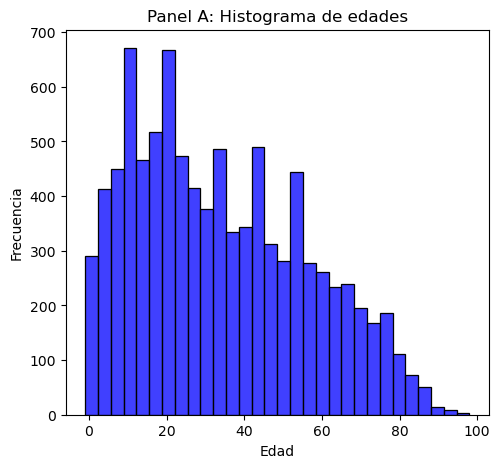

In [78]:
#Panel A
plt.figure(figsize=(12, 5))

# Panel A - Histograma
plt.subplot(1, 2, 1)
sns.histplot(data=base_final, x='CH06', bins=30, kde=False, color='blue', edgecolor='black')
plt.title("Panel A: Histograma de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

In [84]:
#Panel B
base_final['cond_ocup'] = base_final['ESTADO'].replace({1: 'Ocupado', 2: 'Desocupado'})

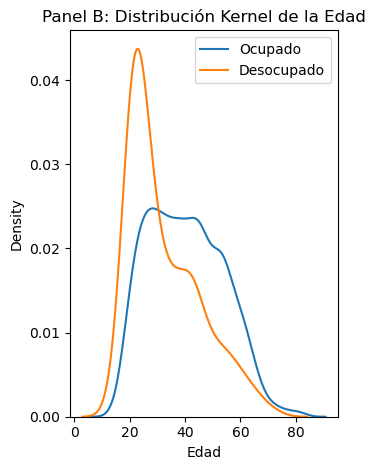

In [88]:
# Panel B - Kernel
plt.subplot(1, 2, 2)
sns.kdeplot(data=base_final[base_final['cond_ocup'] == 'Ocupado'], x='CH06', label='Ocupado', fill=False)
sns.kdeplot(data=base_final[base_final['cond_ocup'] == 'Desocupado'], x='CH06', label='Desocupado', fill=False)
plt.title("Panel B: Distribución Kernel de la Edad")
plt.xlabel("Edad")
plt.legend()

plt.tight_layout()
plt.show()


In [92]:
#2
# Convertimos a string por si hay mezclas de tipos
base_final['CH12'] = base_final['CH12'].astype(str)
base_final['CH13'] = base_final['CH13'].astype(str)
base_final['CH14'] = pd.to_numeric(base_final['CH14'], errors='coerce')
base_final['CH06'] = pd.to_numeric(base_final['CH06'], errors='coerce')

# Mapeamos niveles educativos con años mínimos asociados
mapa_niveles = {
    '1': 0,   # Sin instrucción
    '2': 1,   # Inicial
    '3': 1,   # Primario incompleto
    '4': 7,   # Primario completo
    '5': 8,   # Secundario incompleto
    '6': 12,  # Secundario completo
    '7': 13,  # Terciario / universitario incompleto
    '8': 16,  # Terciario / universitario completo
}

# Asignamos educ base
base_final['educ'] = base_final['CH12'].map(mapa_niveles)

# Si finalizó el nivel, sumamos los años aprobados (CH14)
# De lo contrario, sólo se usa lo que haya completado (o se deja el valor original)
mask_finalizo = base_final['CH13'].str.lower().isin(['sí', 'si', '1'])

base_final.loc[mask_finalizo & base_final['CH14'].notna(), 'educ'] = base_final['CH14']

In [94]:
# Factor de ajuste de precios de 2004 a 2024
factor_ajuste_2004 = 317.8 / 6.1

# Ajustar ingresos de 2004 a precios de 2024
base_final['P21_ajustada'] = base_final.apply(
    lambda row: row['P21'] * factor_ajuste_2004 if row['año'] == 2004 else row['P21'],
    axis=1
)

# Calcular salario_semanal
base_final['salario_semanal'] = base_final['P21_ajustada'] / 40


C:\Users\roman\AppData\Local\Temp\ipykernel_23368\3241333452.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_final['P21_ajustada'] = base_final.apply(
C:\Users\roman\AppData\Local\Temp\ipykernel_23368\3241333452.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_final['salario_semanal'] = base_final['P21_ajustada'] / 40


In [96]:
print (base_final['salario_semanal'])

0        716.352459
1          0.000000
2          0.000000
3          0.000000
4          0.000000
           ...     
9329      -0.225000
9330    4000.000000
9331       0.000000
9332       0.000000
9333       0.000000
Name: salario_semanal, Length: 9334, dtype: float64


In [98]:
base_final = base_final.copy()

C:\Users\roman\AppData\Local\Temp\ipykernel_23368\2938276240.py:17: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


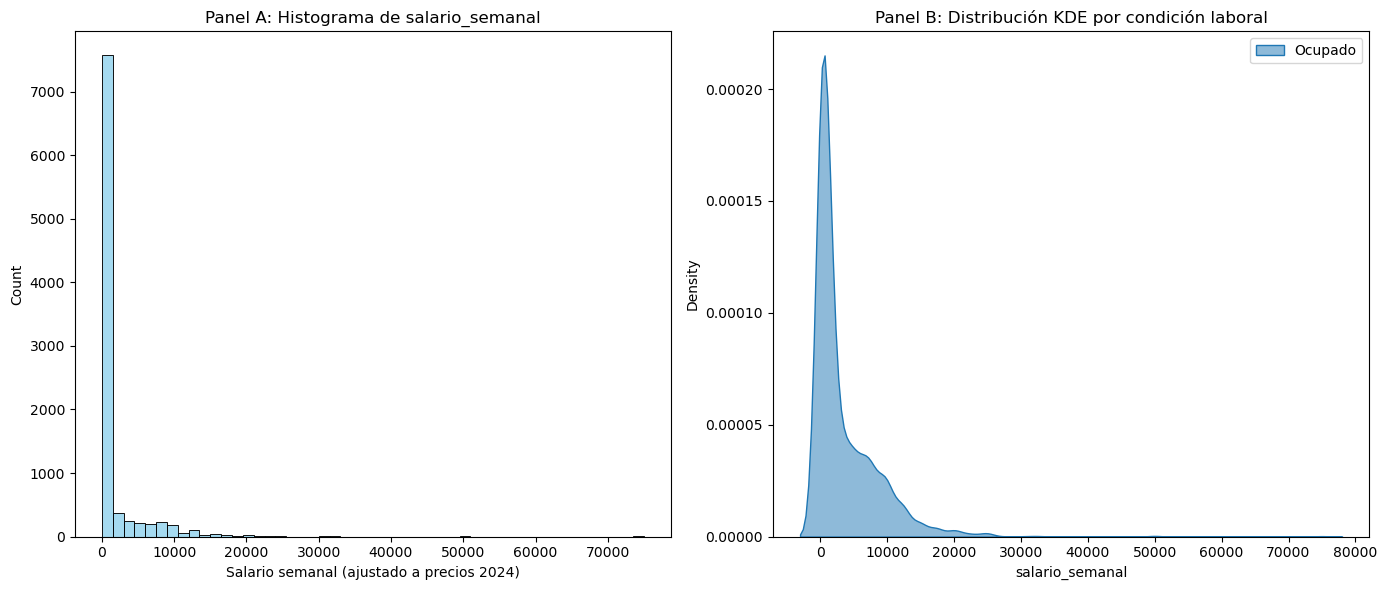

In [102]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Histograma
sns.histplot(base_final['salario_semanal'], bins=50, kde=False, ax=axs[0], color='skyblue')
axs[0].set_title('Panel A: Histograma de salario_semanal')
axs[0].set_xlabel('Salario semanal (ajustado a precios 2024)')

# Panel B: KDE por condición de ocupación
sns.kdeplot(
    data=base_final[base_final['cond_ocup'] == 'Ocupado'],
    x='salario_semanal',
    label='Ocupado',
    fill=True,
    alpha=0.5,
    ax=axs[1]
)
sns.kdeplot(
    data=base_final[base_final['cond_ocup'] == 'Desocupado'],
    x='salario_semanal',
    label='Desocupado',
    fill=True,
    alpha=0.5,
    ax=axs[1]
)
axs[1].set_title('Panel B: Distribución KDE por condición laboral')
axs[1].legend()

plt.tight_layout()
plt.show()

In [104]:
# Crear la variable horastrab
base_final['horastrab'] = base_final['PP3E_TOT'].fillna(0) + base_final['PP3F_TOT'].fillna(0)

# Estadísticas descriptivas
desc_horas = base_final['horastrab'].describe(percentiles=[0.5])
print(desc_horas)

count    9334.000000
mean       15.545425
std        30.399445
min         0.000000
50%         0.000000
max       999.000000
Name: horastrab, dtype: float64


In [108]:
# Contar las observaciones para 2004 y 2024
observaciones_2004 = len(base_final[base_final['año'] == 2004])
observaciones_2024 = len(base_final[base_final['año'] == 2024])

# Contar las observaciones totales
total_observaciones = len(base_final)

# Crear un resumen con los valores
resumen_observaciones = {
    '2004': observaciones_2004,
    '2024': observaciones_2024,
    'Total': total_observaciones
}

resumen_observaciones

{'2004': 4821, '2024': 4513, 'Total': 9334}

In [136]:
# Contar las observaciones con NaN en la variable "cond_ocup"
na_estado_2004 = base_final[base_final['ano4'] == 2004]['cond_ocup'].isna().sum()
na_estado_2024 = base_final[base_final['ano4'] == 2024]['cond_ocup'].isna().sum()
na_estado_total = base_final['cond_ocup'].isna().sum()

# Contar la cantidad de "Ocupados"
ocupados_2004 = (base_final[(base_final['ano4'] == 2004) & (base_final['cond_ocup'] == 'Ocupado')]).shape[0]
ocupados_2024 = (base_final[(base_final['ano4'] == 2024) & (base_final['ESTADO'] == 'Ocupado')]).shape[0]
ocupados_total = (base_final[base_final['ESTADO'] == 'Ocupado']).shape[0]

# Contar la cantidad de "Desocupados"
desocupados_2004 = (base_final[(base_final['ano4'] == 2004) & (base_final['cond_ocup'] == 'Desocupado')]).shape[0]
desocupados_2024 = (base_final[(base_final['ano4'] == 2024) & (base_final['ESTADO'] == 'Desocupado')]).shape[0]
desocupados_total = (base_final[base_final['ESTADO'] == 'Desocupado']).shape[0]

# Resumen de NaN y Ocupados y Desocupados
resumen_na_estado = {
    '2004': na_estado_2004,
    '2024': na_estado_2024,
    'Total': na_estado_total
}

resumen_ocupados = {
    '2004': ocupados_2004,
    '2024': ocupados_2024,
    'Total': ocupados_total
}

resumen_desocupados = {
    '2004': desocupados_2004,
    '2024': desocupados_2024,
    'Total': desocupados_total
}

# Mostrar resultados
print("Resumen de NaN en cond_ocup:", resumen_na_estado)
print("Resumen de Ocupados:", resumen_ocupados)
print("Resumen de Desocupados:", resumen_desocupados)


Resumen de NaN en cond_ocup: {'2004': 0, '2024': 0, 'Total': 0}
Resumen de Ocupados: {'2004': 1897, '2024': 0, 'Total': 1897}
Resumen de Desocupados: {'2004': 223, '2024': 0, 'Total': 223}


In [152]:
print(base_2024['ESTADO'].unique())

[1 3 4 2 0]


In [154]:
ocupados_2024 = (base_2024['ESTADO'] == 'Ocupado').sum()
desocupados_2024 = (base_2024['ESTADO'] == 'Desocupado').sum()

In [156]:
estado_map = {
    1: 'Ocupado',
    2: 'Desocupado',
    3: 'Inactivo',
    4: 'Menor de 10 años',
    0: 'Ns/Nr'
}


In [158]:
# Mapear códigos numéricos a texto en la base 2024
estado_map = {
    1: 'Ocupado',
    2: 'Desocupado',
    3: 'Inactivo',
    4: 'Menor de 10 años',
    0: 'Ns/Nr'
}

base_2024['ESTADO'] = base_2024['ESTADO'].map(estado_map)

# Ahora podés contar correctamente
ocupados_2024 = (base_2024['ESTADO'] == 'Ocupado').sum()
desocupados_2024 = (base_2024['ESTADO'] == 'Desocupado').sum()
na_estado_2024 = base_2024['ESTADO'].isna().sum()


C:\Users\roman\AppData\Local\Temp\ipykernel_23368\3788019787.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_2024['ESTADO'] = base_2024['ESTADO'].map(estado_map)


In [160]:
base_2024.loc[:, 'ESTADO'] = base_2024['ESTADO'].map(estado_map)

In [164]:
# 1. Unificamos columnas comunes
columnas_comunes = list(set(base_2004.columns).intersection(set(base_2024.columns)))
base_2004_final = base_2004[columnas_comunes].copy()
base_2024_final = base_2024[columnas_comunes].copy()

# 2. Aseguramos la columna 'año'
base_2004_final["año"] = 2004
base_2024_final["año"] = 2024

# 3. Concatenamos ambas bases
base_final = pd.concat([base_2004_final, base_2024_final], ignore_index=True)

# 4. Contamos cada métrica
tabla_1 = {
    "Cantidad observaciones": [
        len(base_2004_final),
        len(base_2024_final),
        len(base_final)
    ],
    "Cantidad de observaciones con Nas en la variable “Estado”": [
        base_2004_final['ESTADO'].isna().sum(),
        base_2024_final['ESTADO'].isna().sum(),
        base_final['ESTADO'].isna().sum()
    ],
    "Cantidad de Ocupados": [
        (base_2004_final['ESTADO'] == "Ocupado").sum(),
        (base_2024_final['ESTADO'] == "Ocupado").sum(),
        (base_final['ESTADO'] == "Ocupado").sum()
    ],
    "Cantidad de Desocupados": [
        (base_2004_final['ESTADO'] == "Desocupado").sum(),
        (base_2024_final['ESTADO'] == "Desocupado").sum(),
        (base_final['ESTADO'] == "Desocupado").sum()
    ],
    "Cantidad de variables limpias y homogeneizadas": [
        len(columnas_comunes),
        len(columnas_comunes),
        len(columnas_comunes)
    ]
}

# 5. Crear DataFrame con índices por año
tabla_1_df = pd.DataFrame(tabla_1, index=["2004", "2024", "Total"])
tabla_1_df.T  # Transponer para que años queden como columnas


,2004,2024,Total
Cantidad observaciones,4821,4513,9334
Cantidad de observaciones con Nas en la variable “Estado”,0,4513,4513
Cantidad de Ocupados,1897,0,1897
Cantidad de Desocupados,223,0,223
Cantidad de variables limpias y homogeneizadas,343,343,343


In [166]:
#Parte 2

In [172]:
# Si 'CH06' representa edad:
base_final['edad'] = base_final['CH06']
base_final['edad2'] = base_final['edad'] ** 2

C:\Users\roman\AppData\Local\Temp\ipykernel_23368\3077676439.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_final['edad'] = base_final['CH06']


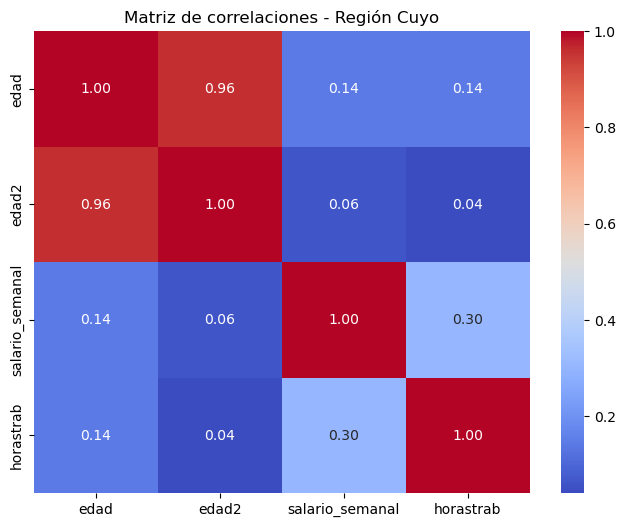

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar variables válidas (sin 'educ' ya que no aparece en los datos)
variables = ['edad', 'edad2', 'salario_semanal', 'horastrab']

# Nos aseguramos de que todas las variables sean válidas y existan en la base
datos_cor = base_final[variables].dropna()

# Calcular la matriz de correlación
correlaciones = datos_cor.corr(numeric_only=True)

# Graficar la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlaciones - Región Cuyo")
plt.show()


In [196]:
#PCA

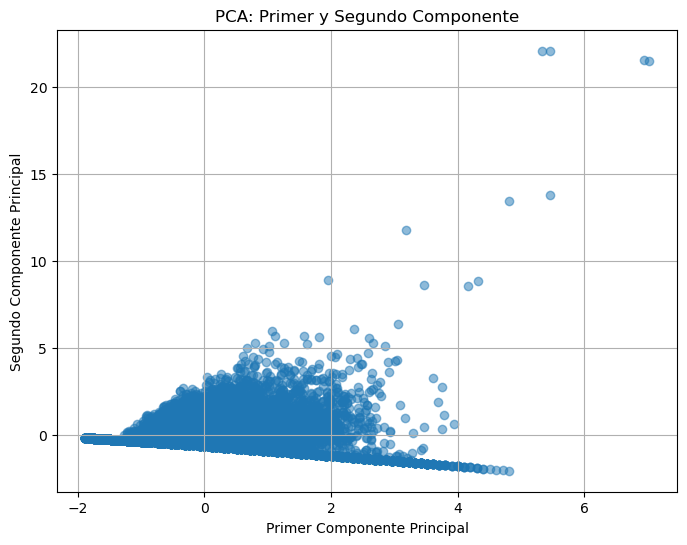

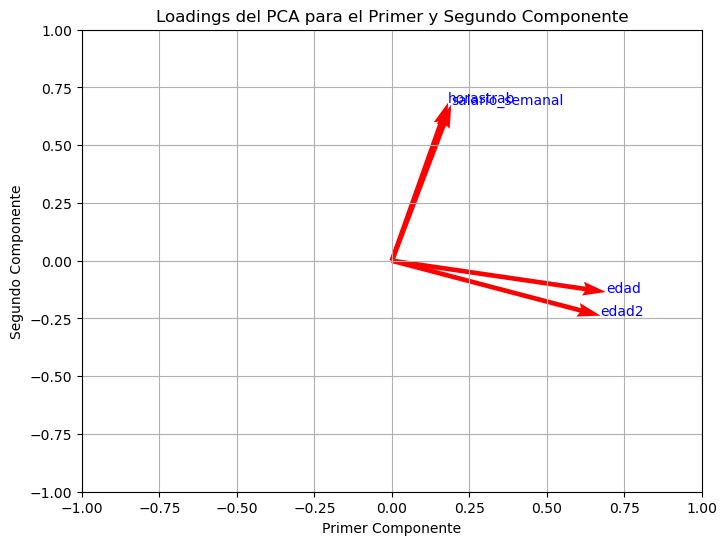

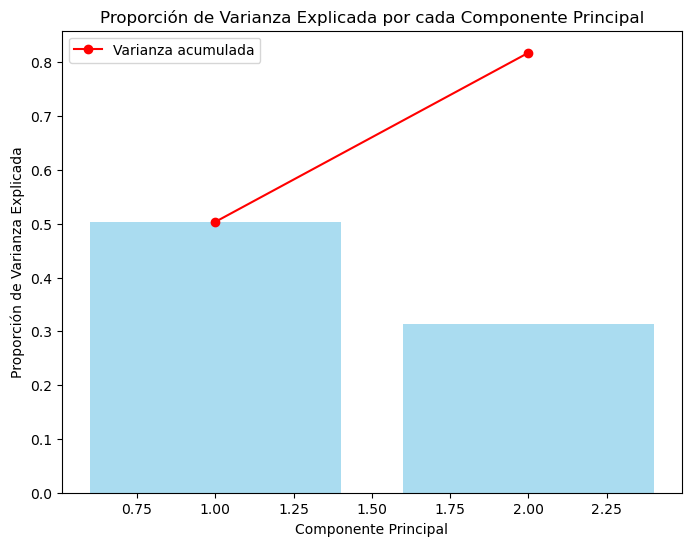

In [198]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar las variables de interés
variables = ['edad', 'edad2', 'salario_semanal', 'horastrab']

# Nos aseguramos de que todas las variables sean válidas
datos_pca = base_final[variables].dropna()

# Estandarizar las variables (media=0, varianza=1)
scaler = StandardScaler()
datos_estandarizados = scaler.fit_transform(datos_pca)

# Aplicar PCA
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(datos_estandarizados)

# Graficar el primer y segundo componente
plt.figure(figsize=(8, 6))
plt.scatter(pca_scores[:, 0], pca_scores[:, 1], alpha=0.5)
plt.title('PCA: Primer y Segundo Componente')
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.grid(True)
plt.show()

# Graficar los loadings de PCA para el primer y segundo componente
plt.figure(figsize=(8, 6))
loading_matrix = pca.components_.T  # Transponer para que las variables estén en las filas
plt.quiver(np.zeros(loading_matrix.shape[0]), np.zeros(loading_matrix.shape[0]),
           loading_matrix[:, 0], loading_matrix[:, 1], angles='xy', scale_units='xy', scale=1, color='r')

# Etiquetas para las variables
for i, var in enumerate(variables):
    plt.text(loading_matrix[i, 0], loading_matrix[i, 1], var, color='blue')

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.title('Loadings del PCA para el Primer y Segundo Componente')
plt.xlabel('Primer Componente')
plt.ylabel('Segundo Componente')
plt.grid(True)
plt.show()

# Graficar la proporción de varianza explicada
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.7, color='skyblue')
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', color='r', label='Varianza acumulada')
plt.title('Proporción de Varianza Explicada por cada Componente Principal')
plt.xlabel('Componente Principal')
plt.ylabel('Proporción de Varianza Explicada')
plt.legend()
plt.show()


In [200]:
#CLUSTER